In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data/german_credit.csv")

df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,job,dependents,telephone,foreign_worker,default
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,1
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,2
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,1
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,skilled employee,2,none,yes,1
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,2


In [6]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_length     1000 non-null   object
 7   installment_rate      1000 non-null   int64 
 8   personal_status       1000 non-null   object
 9   other_debtors         1000 non-null   object
 10  residence_history     1000 non-null   int64 
 11  property              1000 non-null   object
 12  age                   1000 non-null   int64 
 13  installment_plan      1000 non-null   object
 14  housing               1000 non-null   object
 15  existing_credits      1000 non-null   i

In [7]:
df.isnull().sum()


checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_length       0
installment_rate        0
personal_status         0
other_debtors           0
residence_history       0
property                0
age                     0
installment_plan        0
housing                 0
existing_credits        0
job                     0
dependents              0
telephone               0
foreign_worker          0
default                 0
dtype: int64

In [8]:
df["default"].value_counts()

default
1    700
2    300
Name: count, dtype: int64

In [9]:
df["target"] = df["default"].map({
    1: 0,   # Good Credit
    2: 1    # Bad Credit
})

df["target"].value_counts()

target
0    700
1    300
Name: count, dtype: int64

In [10]:
df["target"].value_counts(normalize=True) * 100

target
0    70.0
1    30.0
Name: proportion, dtype: float64

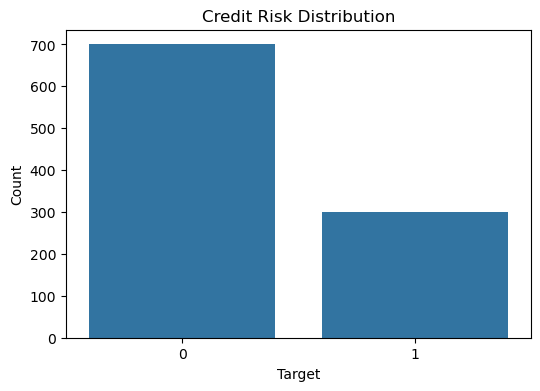

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Credit Risk Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [12]:
df.describe()

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,dependents,default,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000,1.000000


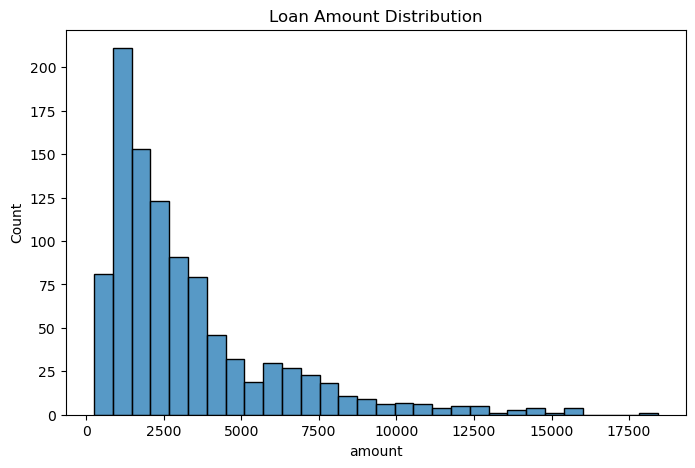

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["amount"],
    bins=30
)

plt.title("Loan Amount Distribution")

plt.show()

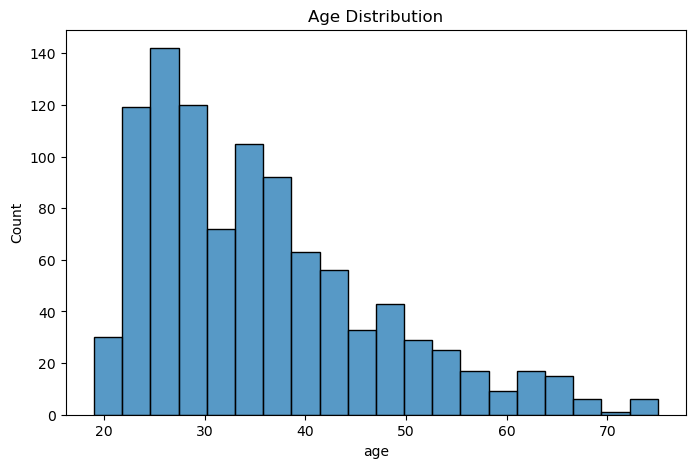

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20
)

plt.title("Age Distribution")

plt.show()

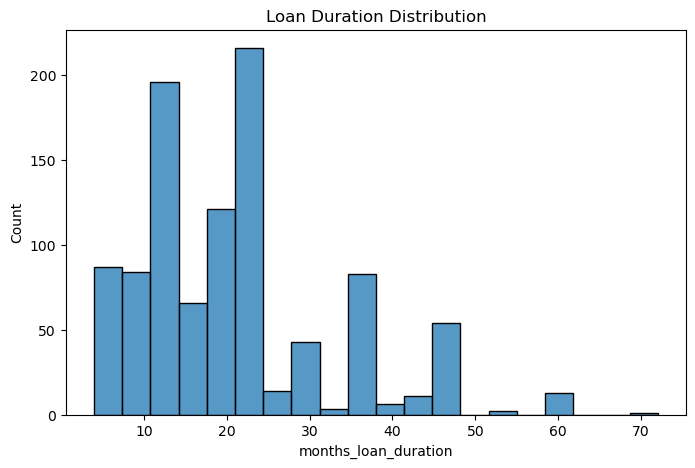

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["months_loan_duration"],
    bins=20
)

plt.title("Loan Duration Distribution")

plt.show()

In [16]:
pd.crosstab(
    df["credit_history"],
    df["target"],
    normalize="index"
).round(3)

target,0,1
credit_history,,
critical,0.829,0.171
delayed,0.682,0.318
fully repaid,0.375,0.625
fully repaid this bank,0.429,0.571
repaid,0.681,0.319


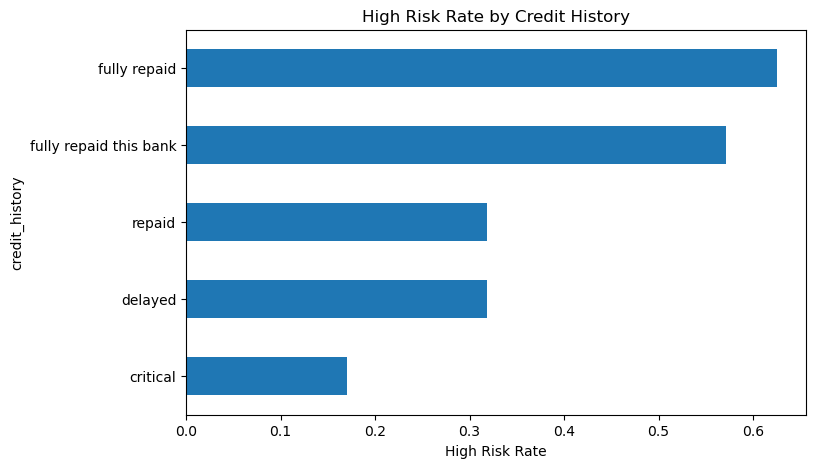

In [17]:
risk_by_history = pd.crosstab(
    df["credit_history"],
    df["target"],
    normalize="index"
)

risk_by_history[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("High Risk Rate by Credit History")
plt.xlabel("High Risk Rate")
plt.show()

In [18]:
pd.crosstab(
    df["checking_balance"],
    df["target"],
    normalize="index"
).round(3)

target,0,1
checking_balance,,
1 - 200 DM,0.610,0.390
< 0 DM,0.507,0.493
> 200 DM,0.778,0.222
unknown,0.883,0.117


In [19]:
pd.crosstab(
    df["savings_balance"],
    df["target"],
    normalize="index"
).round(3)

target,0,1
savings_balance,,
101 - 500 DM,0.670,0.330
501 - 1000 DM,0.825,0.175
< 100 DM,0.640,0.360
> 1000 DM,0.875,0.125
unknown,0.825,0.175


In [20]:
pd.crosstab(
    df["employment_length"],
    df["target"],
    normalize="index"
).round(3)

target,0,1
employment_length,,
0 - 1 yrs,0.593,0.407
1 - 4 yrs,0.693,0.307
4 - 7 yrs,0.776,0.224
> 7 yrs,0.747,0.253
unemployed,0.629,0.371


In [21]:
pd.crosstab(
    df["housing"],
    df["target"],
    normalize="index"
).round(3)

target,0,1
housing,,
for free,0.593,0.407
own,0.739,0.261
rent,0.609,0.391
